In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from tqdm import tqdm

import sys
sys.path.append("../src")


from geodesiq import *

# Double quantum dot model

In [5]:
def dqd_hamiltonian(eps, U, tc, Ez, dEz, dEx):
    ham = np.array([
        [U-eps, 0, -tc, tc, 0],
        [0, Ez, dEx, -dEx, 0],
        [-tc, dEx, dEz, 0, dEx],
        [tc, -dEx, 0, -dEz, -dEx],
        [0, 0, dEx, -dEx, -Ez]
    ])
    return ham


dqd_model = Hamiltonian(dqd_hamiltonian)

# ----- Set system and control parameters -----
alpha, beta = 2, 2

U, tc, Ez, dEz, dEx = 10, 1, .9, .1, .01
eps0, epsf = 15, 0


dqd_model.set_parameters(U=U, tc=tc, Ez=Ez, dEz=dEz, dEx=dEx)
dqd_model.set_control(control_name='eps', pulse_initial=eps0, pulse_final=epsf,
                        initial_state=0, alpha=alpha, beta=beta)

# ----- Solve for optimal pulse -----
dqd_model.solve_problem(pulse_accuracy=int(1000))

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Hamiltonian Eigenvalues'}, xlabel='eps', ylabel='Energy'>)

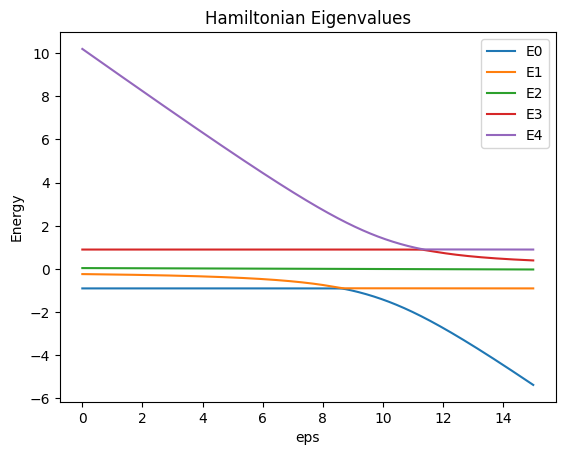

In [6]:
dqd_model.plot_eigenvalues()

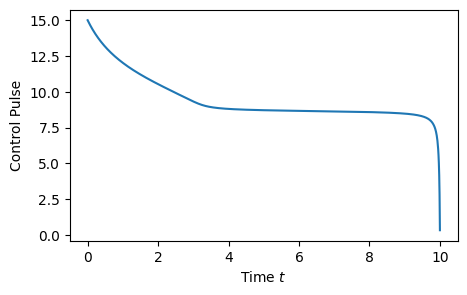

(<Figure size 500x300 with 1 Axes>,
 <Axes: xlabel='Time $t$', ylabel='Control Pulse'>)

In [7]:
pulse = dqd_model.synthesize_pulse(duration=10)
pulse.plot_pulse()

# Time dynamics

In [8]:
def fidelity_vs_time(durations, hamiltonian, alpha=2, beta=2):

    hamiltonian.set_control(alpha=alpha, beta=beta)
    hamiltonian.solve_problem(pulse_accuracy=int(1000))

    fidelities = []
    for duration in tqdm(durations):
        dynamics = Dynamics(duration=duration, hamiltonian=hamiltonian)
        fidelities.append(dynamics.state_fidelity())

    return np.array(fidelities)


durations = np.linspace(0, 1000, 200)
fidelities_geometric = fidelity_vs_time(durations, dqd_model, alpha=2, beta=2)
fidelities_faquad = fidelity_vs_time(durations, dqd_model, alpha=4, beta=2)

100%|██████████| 200/200 [00:41<00:00,  4.81it/s]


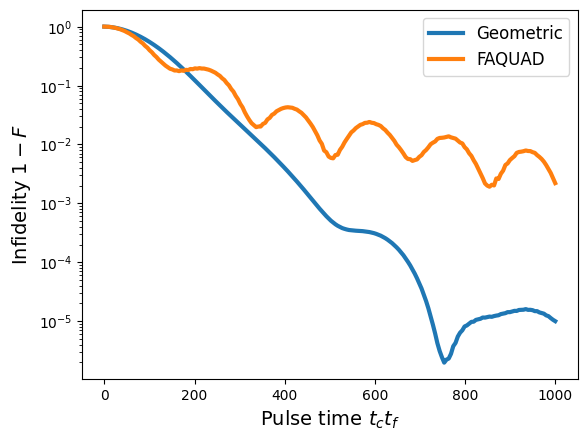

In [9]:
plt.plot(durations, 1-fidelities_geometric, label='Geometric', lw=3)
plt.plot(durations, 1-fidelities_faquad, label='FAQUAD', lw=3)
plt.yscale('log')
plt.ylabel('Infidelity $1-F$', fontsize=14)
plt.xlabel('Pulse time $t_c t_f$', fontsize=14)
plt.legend(fontsize=12)
plt.show()

# $(\alpha,\beta;\hat{\alpha}, \hat{\beta})$ fidelity sweep: pure adiabatic evolution

In [ ]:
from joblib import Parallel, delayed

In [ ]:
def optimal_fidelity_time_map(durations, hamiltonian, alphas, betas):
    """
    Function that computes the fidelity map for a range of alpha and beta values over a range of durations.
    The function relies on the definition of fidelity_vs_time() from above.
    """
    fidelities = np.zeros((len(alphas), len(betas), len(durations)))
    for i, alpha in enumerate(alphas):
        for j, beta in enumerate(betas):
            fidelities[i, j] = fidelity_vs_time(durations, hamiltonian, alpha=alpha, beta=beta)

    max_fidelities = np.max(fidelities, axis=2)
    best_times = durations[np.argmax(fidelities, axis=2)]

    return max_fidelities, best_times

In [ ]:
alphas = np.linspace(0, 5, 5)
betas = np.linspace(0, 5, 5)

optimal_fidelities, best_times = optimal_fidelity_time_map(durations, dqd_model, alphas, betas)

100%|██████████| 200/200 [00:47<00:00,  4.19it/s]
capi_return is NULL
Call-back cb_f_in_zvode__user__routines failed.
 20%|██        | 1/5 [06:39<26:39, 399.80s/it]


KeyboardInterrupt: 

In [ ]:
fontsizes = 14
fontsize_label = 16
colorbar_loc = 'top'
cmap_coloring_fid = 'PuBu_r'
extent = [min(alphas), max(alphas), min(betas), max(betas)]

fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# --- Left Plot: Optimal Fidelity ---
fidelity_error = np.log10(1 - optimal_fidelities.T)

im0 = axs[0].imshow(
    fidelity_error, origin='lower', aspect='auto', 
    interpolation='none', extent=extent, cmap=cmap_coloring_fid
)
axs[0].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
axs[0].set_ylabel(r'$\beta$', fontsize=fontsize_label)
axs[0].tick_params(labelsize=fontsizes)

cbar0 = plt.colorbar(im0, ax=axs[0], location=colorbar_loc, pad=0.05)
cbar0.set_label(r'$\log_{10}(1 - \tilde{\mathcal{F}})$', size=fontsize_label)
cbar0.ax.tick_params(labelsize=fontsizes)


# --- Right Plot: Best Times ---
im1 = axs[1].imshow(
    best_times.T, origin='lower', aspect='auto', 
    interpolation='none', extent=extent, cmap='inferno_r'
)
axs[1].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
axs[1].tick_params(labelsize=fontsizes)

cbar1 = plt.colorbar(im1, ax=axs[1], location=colorbar_loc, pad=0.05)
cbar1.set_label(r'$\tilde{t}_\text{f}\,t_c$', size=fontsize_label)
cbar1.ax.tick_params(labelsize=fontsizes)


plt.tight_layout()
plt.show()